First check if relationship between rho and consistency

In [15]:
import polars as pl
import json
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np 

cons_df = pl.read_csv('../save/ResNet18/models/RSA_consistency.csv')
cons_df = cons_df.with_columns(
    pl.coalesce([
        pl.col("model").str.extract(r"(\d+\.?\d*)rho", 1),  # Before rho
        pl.col("model").str.extract(r"rho(\d+\.?\d*)", 1),  # After rho
    ])
    .cast(pl.Float64)
    .alias("rho")
).filter(pl.col("rho").is_not_null())
cons_df = cons_df['model', 'rho','mean', 'num_trials']
cons_df = cons_df.rename({'mean': 'consistency'})
cons_df

model,rho,consistency,num_trials
str,f64,f64,i64
"""CE_rho0""",0.0,0.830751,5
"""CE_rho0.008""",0.008,0.829816,5
"""CE_rho0.04""",0.04,0.730588,5
"""CE_rho0.2""",0.2,0.611853,5
"""crossentropy_wstopo_grid_256em…",0.0,0.83229,3
"""crossentropy_wstopo_grid_256em…",0.008,0.846644,3
"""crossentropy_wstopo_grid_256em…",0.04,0.704973,3
"""crossentropy_wstopo_grid_256em…",0.2,0.614848,3
"""crossentropy_wstopo_grid_256em…",1.0,0.453041,3


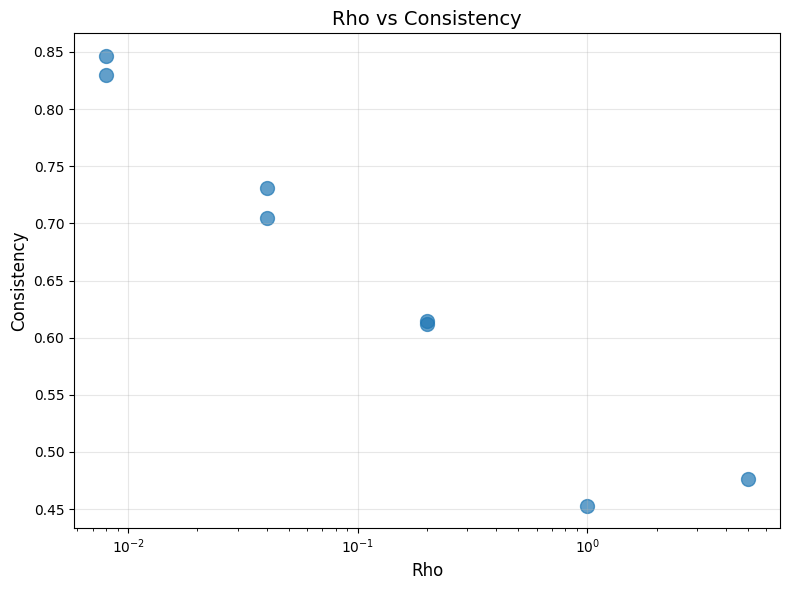

Spearman -->  -0.926
Pearson  -->  -0.647


In [16]:
def scatter_and_corr(col_a, col_b):
    # Extract values for plotting
    rho_values = cons_df[col_a].to_numpy()
    consistency_values = cons_df[col_b].to_numpy()  # Replace with your consistency column name
    # Create scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(rho_values, consistency_values, alpha=0.7, s=100)
    plt.xscale('log')  
    plt.xlabel('Rho', fontsize=12)
    plt.ylabel('Consistency', fontsize=12)
    plt.title('Rho vs Consistency', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Spearman --> ", round(cons_df.select(pl.corr(col_a, col_b, method='spearman')).item(), 3))
    print("Pearson  --> ", round(cons_df.select(pl.corr(col_a, col_b, method='pearson')).item(), 3))

scatter_and_corr("rho", "consistency")


Now we collect ensemble data

In [17]:
import os, json, torch, sys
import numpy as np
import polars as pl
sys.path.append("..")

# Project imports
from utils import env
from utils import ensemble_utils as ens
from utils import run_inference as inf
import exp_diversity as exp

# Configuration
save_dir = "../save/ensembles"
index = ens.load_index(save_dir)

results_list = []

for run_hash in index:
    run_names = index[run_hash]
    
    # Collect Component (Individual Model) Data
    comp_accs = []
    labels = None
    for rn in run_names:
        mod, tri = ens.parse_run_name(rn)
        inf_data = inf.get_or_run_inference(mod, tri)
        comp_accs.append(inf_data['accuracy'])
        if labels is None:
            labels = inf_data['labels'] # Ensure labels are available for ensemble evaluation
            
    comp_accs = np.array(comp_accs)    
    
    # 2. Initialize the row with base stats
    row = {
        "hash": run_hash,
        "comp_max_acc": float(comp_accs.max()),
        "comp_mean_acc": float(comp_accs.mean()),
        "num_models": len(run_names)
    }

    # 3. Retrieve Ensemble Accuracies
    # load_ensemble returns {method_name: probabilities_tensor}
    ensemble_outputs = ens.load_ensemble(save_dir, run_hash)
    for method, probs in ensemble_outputs.items():
        preds = probs.argmax(dim=1)
        # Compare ensemble predictions against ground truth labels
        acc = float((preds == labels).float().mean().item())
        row[f"ens_acc_{method}"] = acc
        md = ens.load_metadata(save_dir, run_hash)
        row["rho"] = md.get('rho', None)
        row["name"] = md.get('name', None)
        

    # 4. Retrieve Diversity Metrics (from diversity.csv)
    # get_diversity_results returns (scalar_dict, pairwise_dict)
    div_scalars, _ = exp.get_diversity_results(run_hash, save_dir)
    row.update(div_scalars)

    results_list.append(row)

# Create Polars DataFrame
ens_df = pl.DataFrame(results_list)

print(f"Collected data for {len(ens_df)} ensembles.")

# # Drop columns that have any null values
# df = df[[s.name for s in df if s.null_count() == 0]]

print(ens_df.head())

Collected data for 8 ensembles.
shape: (5, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ hash      ┆ comp_max_ ┆ comp_mean ┆ num_model ┆ … ┆ ens_acc_c ┆ ens_acc_h ┆ q_statist ┆ pred_dis │
│ ---       ┆ acc       ┆ _acc      ┆ s         ┆   ┆ onf_weigh ┆ ard       ┆ ic        ┆ agreemen │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ted       ┆ ---       ┆ ---       ┆ t        │
│           ┆ f64       ┆ f64       ┆ i64       ┆   ┆ ---       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ a1e45672b ┆ 0.9163    ┆ 0.91316   ┆ 5         ┆ … ┆ 0.9387    ┆ 0.936     ┆ 0.922607  ┆ 0.09459  │
│ 95b068f   ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ d171a509f ┆ 0.9164    ┆ 0.91068   ┆ 5     

Add performance gain over mean

In [18]:
ens_gain_df = ens_df
ens_acc_cols = [col for col in ens_df.columns if col.startswith('ens_acc_')]
print(ens_acc_cols)

# Create gain columns dynamically for both mean and max
for acc_col in ens_acc_cols:
    # Extract method name (e.g., 'ens_acc_soft' -> 'soft')
    method = acc_col.replace('ens_acc_', '')
    
    # Add gain columns: ens_acc_method - comp_mean_acc and ens_acc_method - comp_max_acc
    ens_gain_df = ens_gain_df.with_columns([
        (pl.col(acc_col) - pl.col('comp_mean_acc')).alias(f'ens_gain_mean_{method}'),
        (pl.col(acc_col) - pl.col('comp_max_acc')).alias(f'ens_gain_max_{method}')
    ])

ens_gain_df

['ens_acc_soft', 'ens_acc_max_confidence', 'ens_acc_conf_weighted', 'ens_acc_hard']


hash,comp_max_acc,comp_mean_acc,num_models,ens_acc_soft,rho,name,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,q_statistic,pred_disagreement,ens_gain_mean_soft,ens_gain_max_soft,ens_gain_mean_max_confidence,ens_gain_max_max_confidence,ens_gain_mean_conf_weighted,ens_gain_max_conf_weighted,ens_gain_mean_hard,ens_gain_max_hard
str,f64,f64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""a1e45672b95b068f""",0.9163,0.91316,5,0.9383,0.0,"""CE_rho0""",0.9357,0.9387,0.936,0.922607,0.09459,0.02514,0.022,0.02254,0.0194,0.02554,0.0224,0.02284,0.0197
"""d171a509f132433f""",0.9164,0.91068,5,0.9392,0.2,"""CE_rho0.2""",0.9365,0.9381,0.9376,0.915967,0.09944,0.02852,0.0228,0.02582,0.0201,0.02742,0.0217,0.02692,0.0212
"""bd42f16b6bed4d1f""",0.9165,0.9141,5,0.9396,0.04,"""CE_rho0.04""",0.936,0.9394,0.9374,0.924856,0.09246,0.0255,0.0231,0.0219,0.0195,0.0253,0.0229,0.0233,0.0209
"""b042086518e6c16f""",0.9185,0.91088,5,0.9366,0.008,"""CE_rho0.008""",0.9344,0.937,0.9344,0.922914,0.09663,0.02572,0.0181,0.02352,0.0159,0.02612,0.0185,0.02352,0.0159
"""cd8c55c69a4f2949""",0.9165,0.912367,3,0.9332,0.0,"""crossentropy_wstopo_grid_256em…",0.93,0.9335,0.9294,0.930434,0.092467,0.020833,0.0167,0.017633,0.0135,0.021133,0.017,0.017033,0.0129
"""b7ff5a1bb36b11b9""",0.9153,0.912033,3,0.9319,0.2,"""crossentropy_wstopo_grid_256em…",0.9315,0.9304,0.93,0.920959,0.0953,0.019867,0.0166,0.019467,0.0162,0.018367,0.0151,0.017967,0.0147
"""a46149a6897d5767""",0.916,0.912833,3,0.9327,0.04,"""crossentropy_wstopo_grid_256em…",0.9325,0.9332,0.9287,0.931975,0.090633,0.019867,0.0167,0.019667,0.0165,0.020367,0.0172,0.015867,0.0127
"""664d92e5ca1187b1""",0.9163,0.9094,3,0.9323,0.008,"""crossentropy_wstopo_grid_256em…",0.9298,0.9321,0.927,0.924407,0.096633,0.0229,0.016,0.0204,0.0135,0.0227,0.0158,0.0176,0.0107


Now join, so to have detailed info about each ensemble

In [19]:
# display(cons_df.head())
# display(ens_gain_df.head())

joined_df = cons_df.join(ens_gain_df, left_on="model", right_on="name")
joined_df

model,rho,consistency,num_trials,hash,comp_max_acc,comp_mean_acc,num_models,ens_acc_soft,rho_right,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,q_statistic,pred_disagreement,ens_gain_mean_soft,ens_gain_max_soft,ens_gain_mean_max_confidence,ens_gain_max_max_confidence,ens_gain_mean_conf_weighted,ens_gain_max_conf_weighted,ens_gain_mean_hard,ens_gain_max_hard
str,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CE_rho0""",0.0,0.830751,5,"""a1e45672b95b068f""",0.9163,0.91316,5,0.9383,0.0,0.9357,0.9387,0.936,0.922607,0.09459,0.02514,0.022,0.02254,0.0194,0.02554,0.0224,0.02284,0.0197
"""CE_rho0.008""",0.008,0.829816,5,"""b042086518e6c16f""",0.9185,0.91088,5,0.9366,0.008,0.9344,0.937,0.9344,0.922914,0.09663,0.02572,0.0181,0.02352,0.0159,0.02612,0.0185,0.02352,0.0159
"""CE_rho0.04""",0.04,0.730588,5,"""bd42f16b6bed4d1f""",0.9165,0.9141,5,0.9396,0.04,0.936,0.9394,0.9374,0.924856,0.09246,0.0255,0.0231,0.0219,0.0195,0.0253,0.0229,0.0233,0.0209
"""CE_rho0.2""",0.2,0.611853,5,"""d171a509f132433f""",0.9164,0.91068,5,0.9392,0.2,0.9365,0.9381,0.9376,0.915967,0.09944,0.02852,0.0228,0.02582,0.0201,0.02742,0.0217,0.02692,0.0212
"""crossentropy_wstopo_grid_256em…",0.0,0.83229,3,"""cd8c55c69a4f2949""",0.9165,0.912367,3,0.9332,0.0,0.93,0.9335,0.9294,0.930434,0.092467,0.020833,0.0167,0.017633,0.0135,0.021133,0.017,0.017033,0.0129
"""crossentropy_wstopo_grid_256em…",0.008,0.846644,3,"""664d92e5ca1187b1""",0.9163,0.9094,3,0.9323,0.008,0.9298,0.9321,0.927,0.924407,0.096633,0.0229,0.016,0.0204,0.0135,0.0227,0.0158,0.0176,0.0107
"""crossentropy_wstopo_grid_256em…",0.04,0.704973,3,"""a46149a6897d5767""",0.916,0.912833,3,0.9327,0.04,0.9325,0.9332,0.9287,0.931975,0.090633,0.019867,0.0167,0.019667,0.0165,0.020367,0.0172,0.015867,0.0127
"""crossentropy_wstopo_grid_256em…",0.2,0.614848,3,"""b7ff5a1bb36b11b9""",0.9153,0.912033,3,0.9319,0.2,0.9315,0.9304,0.93,0.920959,0.0953,0.019867,0.0166,0.019467,0.0162,0.018367,0.0151,0.017967,0.0147


In [20]:
ens_acc_cols = [col for col in joined_df.columns if col.startswith('ens_acc_')]
print(ens_acc_cols)
ens_gain_mean = [col.replace('ens_acc_', 'ens_gain_mean_') for col in ens_acc_cols]

joined_df = joined_df[['rho', 'consistency'] + ens_gain_mean]

joined_df


# # Plot rho vs ensemble gain metrics
# plt.figure(figsize=(10, 6))
# labels = ['Soft', 'Max Confidence', 'Conf Weighted', 'Hard']
# for col, label in zip(ens_gain_mean, labels):
#     # Scatter plot rho on x and the gain metric on y
#     plt.scatter(fdf['rho'], fdf[col], label=label, alpha=0.7, s=80)
# plt.xlabel('rho', fontsize=12)
# plt.ylabel('Ensemble Gain (Mean)', fontsize=12)
# plt.title('Ensemble Gain vs Rho', fontsize=14)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

['ens_acc_soft', 'ens_acc_max_confidence', 'ens_acc_conf_weighted', 'ens_acc_hard']


rho,consistency,ens_gain_mean_soft,ens_gain_mean_max_confidence,ens_gain_mean_conf_weighted,ens_gain_mean_hard
f64,f64,f64,f64,f64,f64
0.0,0.830751,0.02514,0.02254,0.02554,0.02284
0.008,0.829816,0.02572,0.02352,0.02612,0.02352
0.04,0.730588,0.0255,0.0219,0.0253,0.0233
0.2,0.611853,0.02852,0.02582,0.02742,0.02692
0.0,0.83229,0.020833,0.017633,0.021133,0.017033
0.008,0.846644,0.0229,0.0204,0.0227,0.0176
0.04,0.704973,0.019867,0.019667,0.020367,0.015867
0.2,0.614848,0.019867,0.019467,0.018367,0.017967


Now compare ensemble gain and diversity (expected from literature)

In [ ]:
# Plot rho vs ensemble gain metrics
plt.figure(figsize=(10, 6))
labels = ['Soft', 'Max Confidence', 'Conf Weighted', 'Hard']
for col, label in zip(ens_gain_mean, labels):
    # Scatter plot rho on x and the gain metric on y
    plt.scatter(full_df['rho'], full_df[col], label=label, alpha=0.7, s=80)
plt.xlabel('rho', fontsize=12)
plt.ylabel('Ensemble Gain (Mean)', fontsize=12)
plt.title('Ensemble Gain vs Rho', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

NameError: name 'full_df' is not defined

<Figure size 1000x600 with 0 Axes>

: 